In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split("\\")[-1]
print(case[0])

D:\Promotion\neurolib\GUI\gui\data\000001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(cntrl_vars, max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

1039


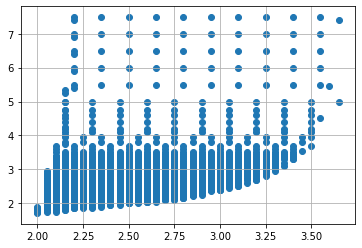

In [4]:
##### LOAD BOUNDARIES
data_file = 'bistability_exc_inh_' + case + '.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

trans_time_array = np.zeros(( len(c_var) ))
trans_time_array[:] = 0.8

In [7]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0':
    cntrl_vars = c_var[0]
elif case[4] == '1':
    cntrl_vars = c_var[1]
    
if case[5] =='1':
    trans_time_array[:] = 0.

prec_vars = p_var[0]

trans_time = trans_time_array[0]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars, maxC[0], maxC[1], maxC[2], maxC[3])

In [8]:
i_range = range(0, len(exc),97)

factor_iteration = 4

prev_i = -1
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.ext_exc_current = exc[i]
    aln.params.ext_inh_current = inh[i]
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    # set low state rates as target
    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]
        
    cost.setParams(1.0, 0.0, 1.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]
    
##### initial guess
    weight_s = 10
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    if prev_i != -1:
        control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_s = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 3.65 7.4
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  169558.71127228247
Gradient descend method:  None
RUN  0 , total integrated cost =  169558.71127228247
Improved over  0  iterations in  0.0  seconds by  0.0  percent.


ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -55.05545353443559 -55.05545143818019
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  169558.71127228247
Gradient descend method:  HS
RUN  1 , total integrated cost =  4639.0510380773985
RUN  2 , total integrated cost =  4070.761415240297
RUN  3 , total integrated cost =  1182.3042066928758
RUN  4 , total integrated cost =  561.1135867489578
RUN  5 , total integrated cost =  365.72221898966313
RUN  6 , total integrated cost =  279.3645847612701
RUN  7 , total integrated cost =  225.64109015240456
RUN  8 , total integrated cost =  195.15070502070526
RUN  9 , total integrated cost =  178.1366940825314
RUN  10 , total integrated cost =  166.97041549591546
RUN  11 , total integrated cost =  158.72989624686267
RUN  12 , total integrated cost =  152.6762024316365
RUN  13 , total integrated cost =  147.4412029513775
RUN  14 , total integrated cost =  142.58809300314823
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  85 , total integrated cost =  120.16058853072212
Improved over  85  iterations in  14.757264300000315  seconds by  99.92913334406171  percent.
Problem in initial value trasfer:  Vmean_exc -56.382402282063694 -56.3824025313939
weight sparsity =  14111.008721377098
set cost params:  1.0 0.0 14111.008721377098
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  112046.7377030234
Gradient descend method:  None
RUN  1 , total integrated cost =  24461.129418833338
RUN  2 , total integrated cost =  22342.86161105289
RUN  3 , total integrated cost =  20946.006759414144
RUN  4 , total integrated cost =  20694.121303349
RUN  5 , total integrated cost =  20608.319892958323
RUN  6 , total integrated cost =  20586.86380123841
RUN  7 , total integrated cost =  20580.817433206077
RUN  8 , total integrated cost =  20579.42627905065
RUN  9 , total integrated cost =  20578.73127365603
RUN  10 , total integrated cost =  20578.643752348537
RUN  11 

...

RUN  400 , total integrated cost =  439.0195103559586
RUN  400 , total integrated cost =  439.0195103559586
Improved over  400  iterations in  11.387277099999665  seconds by  98.57265510328803  percent.
Problem in initial value trasfer:  Vmean_exc -55.91380397847334 -55.913806267507354
-------  970 2.4499999999999997 4.75
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  41831.45826727739
Gradient descend method:  None
RUN  0 , total integrated cost =  41831.45826727739
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
weight sparsity =  10
set cost params:  1.0 0.0 10
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  530.2781131416418
Gradient descend method:  HS
RUN  1 , total integrated cost =  527.3121200704772
RUN  2 , total integrated cost =  523.1955831904838
RUN  3 , total integrated cost =  522.4253832169361
RUN  4 , total integrated cost =  522.182580278552
RUN  5 , total integrated cost =

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  520.3551359859658
Control only changes marginally.
RUN  13 , total integrated cost =  520.3551359859658
Improved over  13  iterations in  1.1724489999996877  seconds by  1.8712779030020954  percent.
Problem in initial value trasfer:  Vmean_exc -56.05936682025632 -56.0593741450264
weight sparsity =  803.9020925202437
set cost params:  1.0 0.0 803.9020925202437
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13303.149446126296
Gradient descend method:  None
RUN  1 , total integrated cost =  12903.160699482745
RUN  2 , total integrated cost =  12798.065757094597
RUN  3 , total integrated cost =  12709.674346349095
RUN  4 , total integrated cost =  12656.17045565277
RUN  5 , total integrated cost =  12602.742863254896
RUN  6 , total integrated cost =  12576.092378840316
RUN  7 , total integrated cost =  12547.632784565238
RUN  8 , total integrated cost =  12528.272364358905
RUN  9 , total integrated cost =  12504.64918039356
RUN  1

ERROR:root:Problem in initial value trasfer


RUN  170 , total integrated cost =  11780.896578082331
Control only changes marginally.
RUN  173 , total integrated cost =  11780.896578082327
Improved over  173  iterations in  6.758503099999871  seconds by  11.442800625585917  percent.
Problem in initial value trasfer:  Vmean_exc -56.059536314328525 -56.05953627038855


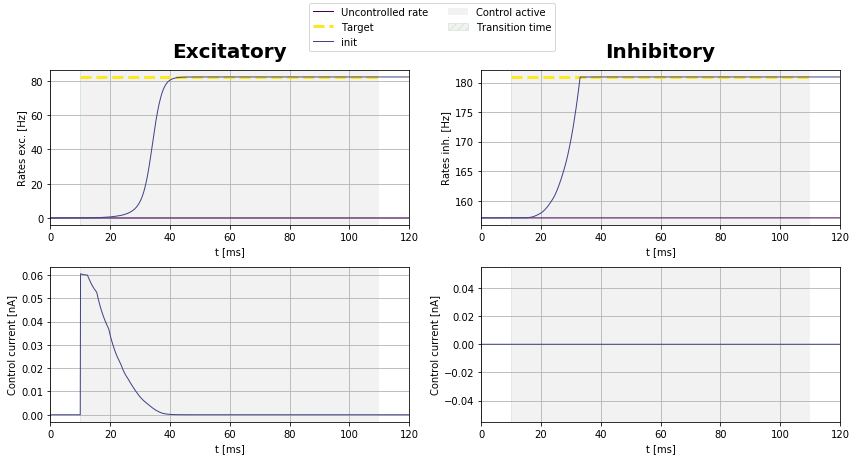

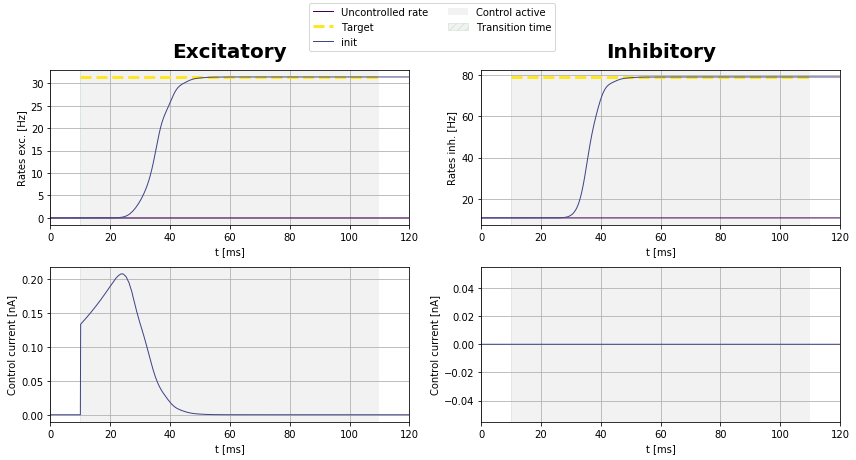

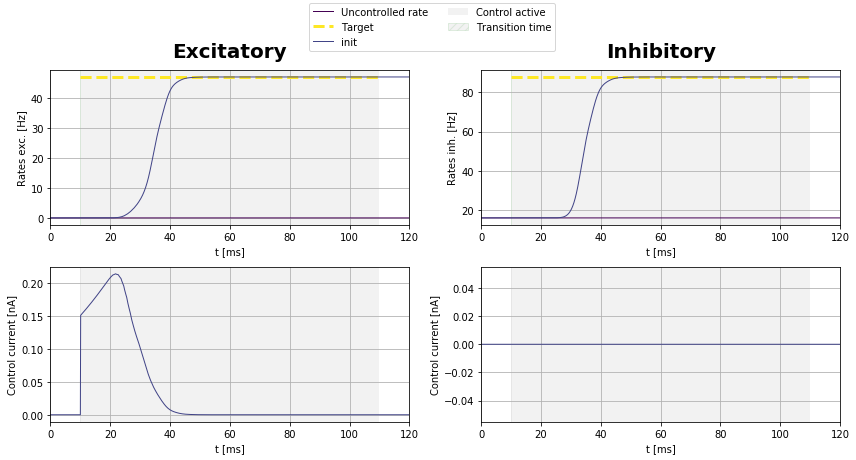

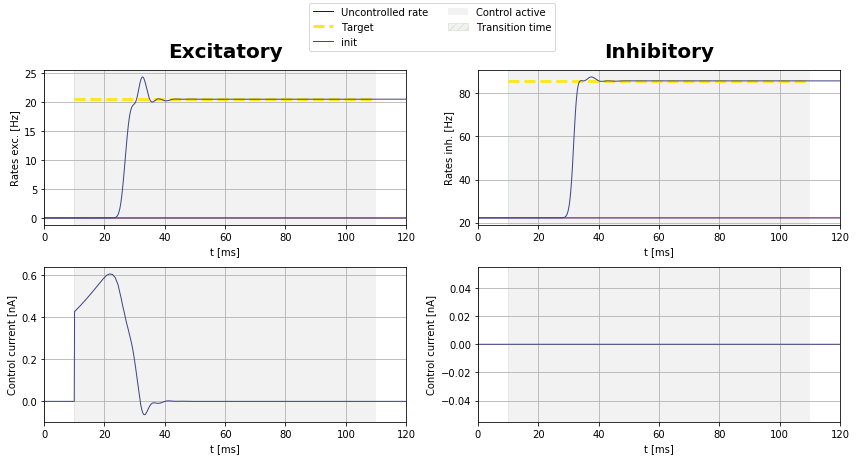

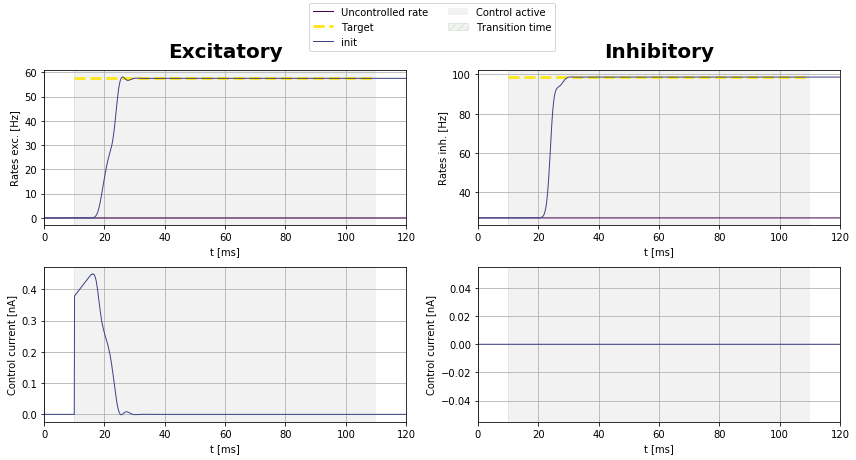

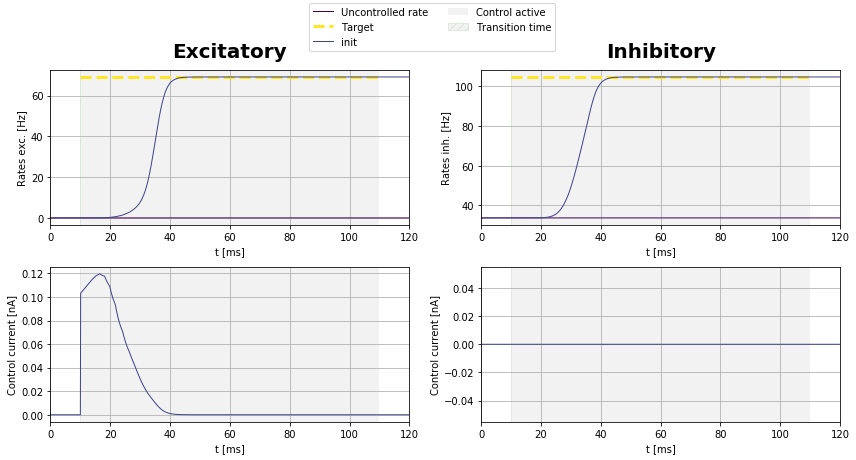

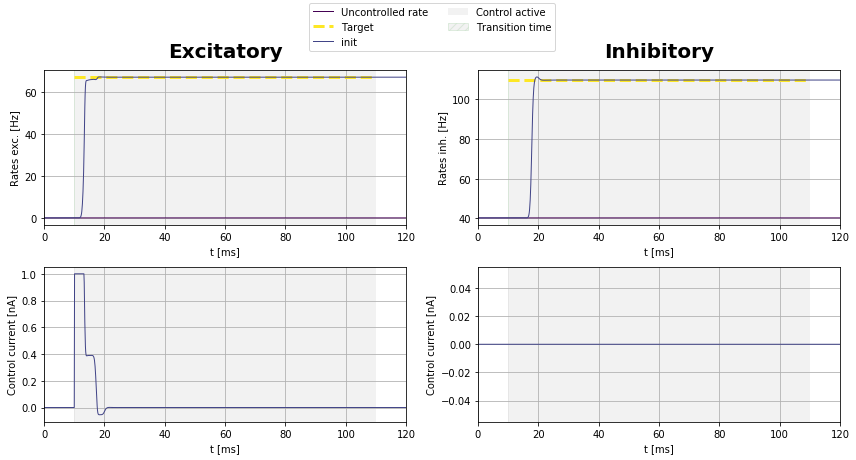

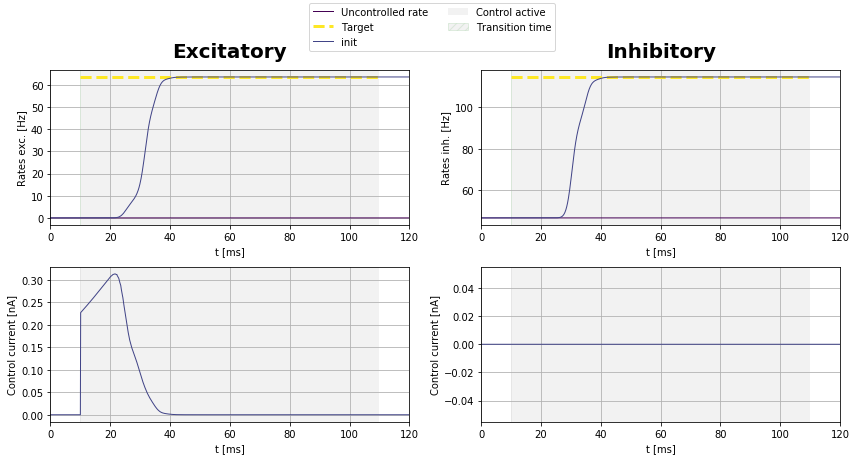

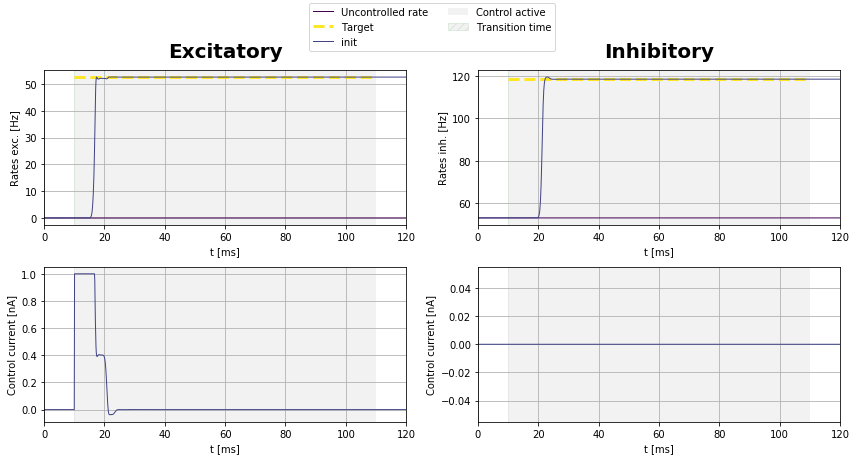

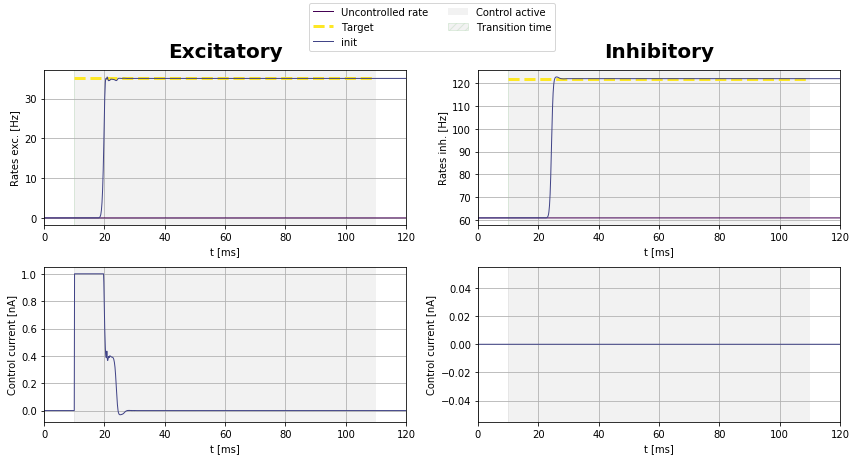

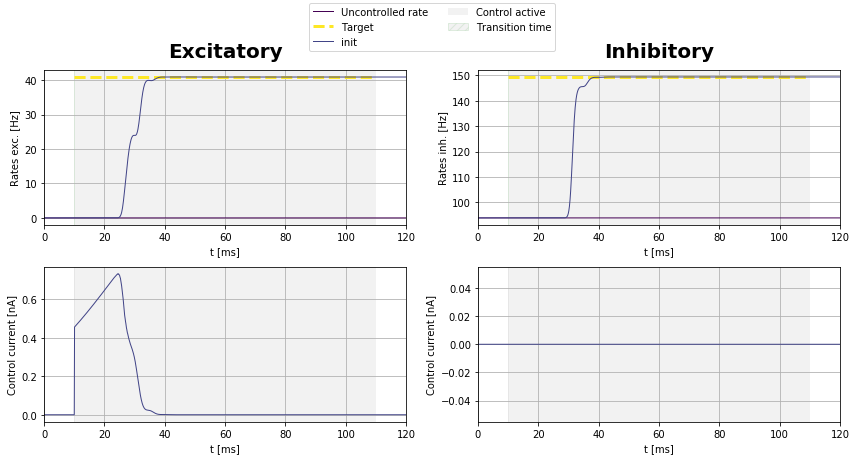

In [9]:
#plot initial guesses

for i in i_range:
    
    aln.params.ext_exc_current = exc[i]
    aln.params.ext_inh_current = inh[i]

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [19]:
for k in range(1):

    factor_iteration = 6

    for i in i_range:
        
        #if i not in [174]:
        #    continue
        

        print("------- ", i, exc[i], inh[i])
        aln.params.ext_exc_current = exc[i]
        aln.params.ext_inh_current = inh[i]

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_s = weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j] - 1
        print("weight sparsity = ", weight_s)
        cost.setParams(1.0, 0.0, weight_s)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 250 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 3.65 7.4
weight sparsity =  459150.5372792999
set cost params:  1.0 0.0 459150.5372792999
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  169535.100677736
Gradient descend method:  None
RUN  1 , total integrated cost =  169535.100677736
Control only changes marginally.
RUN  1 , total integrated cost =  169535.100677736
Improved over  1  iterations in  0.07469230000060634  seconds by  0.0  percent.
-------  97 2.1499999999999995 2.0
weight sparsity =  5890.4952181104345
set cost params:  1.0 0.0 5890.4952181104345
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24678.61809809981
Gradient descend method:  None
RUN  1 , total integrated cost =  24678.61809809981
Control only changes marginally.
RUN  1 , total integrated cost =  24678.61809809981
Improved over  1  iterations in  0.0636956000007558  seconds by  0.0  percent.
-------  194 2.4999999999999982 2.2
weight sparsity =  13724.218578831647
set cost params:  1.0 0.0 13724.218

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  55057.25367841598
Control only changes marginally.
RUN  1 , total integrated cost =  55057.25367841598
Improved over  1  iterations in  0.0709487000003719  seconds by  0.0  percent.
-------  291 2.05 2.4
weight sparsity =  981.3664479270446
set cost params:  1.0 0.0 981.3664479270446
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10447.01316436903
Gradient descend method:  None
RUN  1 , total integrated cost =  10447.01316436903
Control only changes marginally.
RUN  1 , total integrated cost =  10447.01316436903
Improved over  1  iterations in  0.07884419999936654  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.18656493192344 -55.18656535953418
-------  388 2.799999999999997 2.55
weight sparsity =  17946.399017731434
set cost params:  1.0 0.0 17946.399017731434
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  82629.1846334689
Gradient descend method:  None
RUN  1 , total integr

In [20]:
init_file = 'control_init_' + case + '.pickle'

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, costnode_init, weights_init], f)
    
with open(init_file,'rb') as f:
    load_array = pickle.load(f)
    
print(len(load_array))

#bestControl_init = load_array[0]
#costnode_init = load_array[1]
#weights_init = load_array[2]

3


In [21]:
cntrl_vars = c_var[2]
prec_vars = p_var[0]

trans_time = trans_time_array[0]

factor_iteration = 5.
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.ext_exc_current = exc[i]
    aln.params.ext_inh_current = inh[i]

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 25 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_s = 100
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 25 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_s = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 250 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 3.65 7.4
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63715.87809054074
Gradient descend method:  None
RUN  1 , total integrated cost =  2097.514415984933
RUN  2 , total integrated cost =  771.3534755460055
RUN  3 , total integrated cost =  531.1412816426387
RUN  4 , total integrated cost =  401.2795539148857
RUN  5 , total integrated cost =  344.05659193343666
RUN  6 , total integrated cost =  277.7465799282439
RUN  7 , total integrated cost =  240.0282953502409
RUN  8 , total integrated cost =  222.47727350455148
RUN  9 , total integrated cost =  210.53686876396296
RUN  10 , total integrated cost =  200.0665954520637
RUN  11 , total integrated cost =  191.71660240149555
RUN  12 , total integrated cost =  185.63754669231741
RUN  13 , total integrated cost =  180.27215873796854
RUN  14 , total integrated cost =  175.43694405470194
RUN  15 , total integrated cost =  171.55609555034815
RUN  16 , total integrated cost = 

ERROR:root:Problem in initial value trasfer


RUN  125 , total integrated cost =  120.69601793660965
Improved over  125  iterations in  8.344932199999676  seconds by  99.81057152227409  percent.
Problem in initial value trasfer:  Vmean_exc -56.38241664120697 -56.38241443250009
weight sparsity =  100
set cost params:  1.0 0.0 100
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  830.5452679987304
Gradient descend method:  HS
RUN  1 , total integrated cost =  743.0002221480065
RUN  2 , total integrated cost =  738.8975766658367
RUN  3 , total integrated cost =  722.3832597489793
RUN  4 , total integrated cost =  721.4708332901637
RUN  5 , total integrated cost =  718.5897421492564
RUN  6 , total integrated cost =  718.2693097161664
RUN  7 , total integrated cost =  717.9559738464095
RUN  8 , total integrated cost =  717.8781624695741
RUN  9 , total integrated cost =  717.8252783341835
RUN  10 , total integrated cost =  717.7807461124262
RUN  11 , total integrated cost =  717.759867831594
RUN  12 , total integra

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  29 , total integrated cost =  717.3520371897972
Improved over  29  iterations in  3.94906759999958  seconds by  13.628785229453172  percent.
Problem in initial value trasfer:  Vmean_exc -56.38239281230917 -56.38239483739085
weight sparsity =  23635.75050488782
set cost params:  1.0 0.0 23635.75050488782
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  133641.68682840568
Gradient descend method:  None
RUN  1 , total integrated cost =  32469.568143012893
RUN  2 , total integrated cost =  28509.385263303535
RUN  3 , total integrated cost =  28093.59929403999
RUN  4 , total integrated cost =  28041.072985810933
RUN  5 , total integrated cost =  28030.42629764514
RUN  6 , total integrated cost =  28028.150377528036
RUN  7 , total integrated cost =  28027.45697041923
RUN  8 , total integrated cost =  28027.417503600285
RUN  9 , total integrated cost =  28027.322142156372
RUN  10 , total integrated cost =  28027.207828151993
RUN  11

...

RUN  125 , total integrated cost =  1243.6418767287578
Improved over  125  iterations in  7.292696100000285  seconds by  66.78788427090558  percent.
Problem in initial value trasfer:  Vmean_exc -56.06321789920797 -56.06304497425173
weight sparsity =  100
set cost params:  1.0 0.0 100
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2474.576321532615
Gradient descend method:  HS
RUN  1 , total integrated cost =  2467.2834961047133
RUN  2 , total integrated cost =  2447.1481352520823
RUN  3 , total integrated cost =  2406.7340769933817
RUN  4 , total integrated cost =  2396.671989526554
RUN  5 , total integrated cost =  2380.064602036661
RUN  6 , total integrated cost =  2353.663557195934
RUN  7 , total integrated cost =  2335.11333810123
RUN  8 , total integrated cost =  2317.9602635133997
RUN  9 , total integrated cost =  2305.4491611075982
RUN  10 , total integrated cost =  2288.972930545975
RUN  11 , total integrated cost =  2273.506963445118
RUN  12 , total in

ERROR:root:Problem in initial value trasfer


RUN  80 , total integrated cost =  1961.7158804490857
Control only changes marginally.
RUN  81 , total integrated cost =  1961.7158804490857
Improved over  81  iterations in  9.475642100000186  seconds by  20.7251817865085  percent.
Problem in initial value trasfer:  Vmean_exc -56.05850128754551 -56.058569390516936
weight sparsity =  2131.391274607061
set cost params:  1.0 0.0 2131.391274607061
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34080.583812599354
Gradient descend method:  None
RUN  1 , total integrated cost =  32670.734960848986
RUN  2 , total integrated cost =  32560.87049327443
RUN  3 , total integrated cost =  32423.288497013065
RUN  4 , total integrated cost =  32344.802142592227
RUN  5 , total integrated cost =  32246.972280464423
RUN  6 , total integrated cost =  32180.61708853695
RUN  7 , total integrated cost =  32093.658912859475
RUN  8 , total integrated cost =  32036.515177481484
RUN  9 , total integrated cost =  31962.3524126104
RUN  10

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  241 , total integrated cost =  28092.721059222873
Improved over  241  iterations in  39.35270969999965  seconds by  17.56971883551715  percent.
Problem in initial value trasfer:  Vmean_exc -56.05957671484665 -56.05957454678271


In [ ]:
for i in i_range:
    
    aln.params.ext_exc_current = params_bistability_exc[i]
    aln.params.ext_inh_current = params_bistability_inh[i]

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], path, filename_ = case, transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)])

In [31]:
factor_iteration = 5
    
for i in i_range:

    
    print("------- ", i, exc[i], inh[i])
    aln.params.ext_exc_current = exc[i]
    aln.params.ext_inh_current = inh[i]
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_s = weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight sparsity = ", weight_s)
    cost.setParams(1.0, 0.0, weight_s)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 250 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 3.65 7.4
weight sparsity =  458650.22055465385
set cost params:  1.0 0.0 458650.22055465385
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  169420.22927000574
Gradient descend method:  None
RUN  1 , total integrated cost =  169420.22927000574
Control only changes marginally.
RUN  1 , total integrated cost =  169420.22927000574
Improved over  1  iterations in  0.23525429999972403  seconds by  0.0  percent.
-------  97 2.1499999999999995 2.0
weight sparsity =  11431.39117350399
set cost params:  1.0 0.0 11431.39117350399
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24680.64794529693
Gradient descend method:  None
RUN  1 , total integrated cost =  24680.64794529693
Control only changes marginally.


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  24680.64794529693
Improved over  1  iterations in  0.19413750000057917  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.79266457594421 -55.79266488775144
-------  194 2.4999999999999982 2.2
weight sparsity =  26206.554783811873
set cost params:  1.0 0.0 26206.554783811873
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  55059.16326147209
Gradient descend method:  None
RUN  1 , total integrated cost =  55059.16326147209
Control only changes marginally.
RUN  1 , total integrated cost =  55059.16326147209
Improved over  1  iterations in  0.22203799999988405  seconds by  0.0  percent.
-------  291 2.05 2.4
weight sparsity =  1681.9753621221525
set cost params:  1.0 0.0 1681.9753621221525
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10451.44419421683
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10451.44419421683
Control only changes marginally.
RUN  1 , total integrated cost =  10451.44419421683
Improved over  1  iterations in  0.19622109999909298  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.17312717538072 -55.17316646348977
-------  388 2.799999999999997 2.55
weight sparsity =  17946.389738591475
set cost params:  1.0 0.0 17946.389738591475
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  82629.17895575587
Gradient descend method:  None
RUN  1 , total integrated cost =  82629.17895575587
Control only changes marginally.
RUN  1 , total integrated cost =  82629.17895575587
Improved over  1  iterations in  0.2355241000004753  seconds by  0.0  percent.
-------  485 3.149999999999996 2.75
weight sparsity =  67550.32611904493
set cost params:  1.0 0.0 67550.32611904493
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  119465.50076714388
Gradient descend method:  None
RUN  

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  30744.80875261287
Control only changes marginally.
RUN  1 , total integrated cost =  30744.80875261287
Improved over  1  iterations in  0.2086451000013767  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.91388248090362 -55.91388223910427
-------  970 2.4499999999999997 4.75
weight sparsity =  3306.8669390643745
set cost params:  1.0 0.0 3306.8669390643745
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  41818.812209869415
Gradient descend method:  None
RUN  1 , total integrated cost =  41818.812209869415
Control only changes marginally.
RUN  1 , total integrated cost =  41818.812209869415
Improved over  1  iterations in  0.21394529999997758  seconds by  0.0  percent.


In [32]:
final_file = 'control_0_' + case + '.pickle'

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, costnode_0, weights_0], f)
    
with open(final_file,'rb') as f:
    load_array = pickle.load(f)
    
print(len(load_array))

#bestControl_0 = load_array[0]
#costnode_0 = load_array[1]
#weights_0 = load_array[2]

3
